**Importing the Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Loading the data and removing unnecessary column from the dataframe**

In [4]:
df=pd.read_csv("/content/Flight_Booking.csv", on_bad_lines='skip')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Checking the shape of a dataframe and datatypes of
all columns along with calculating the statistical
data

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


**Checking out the missing values in a dataframe**

In [6]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


**Data Visualization**

There is a variation in price with
different airlines

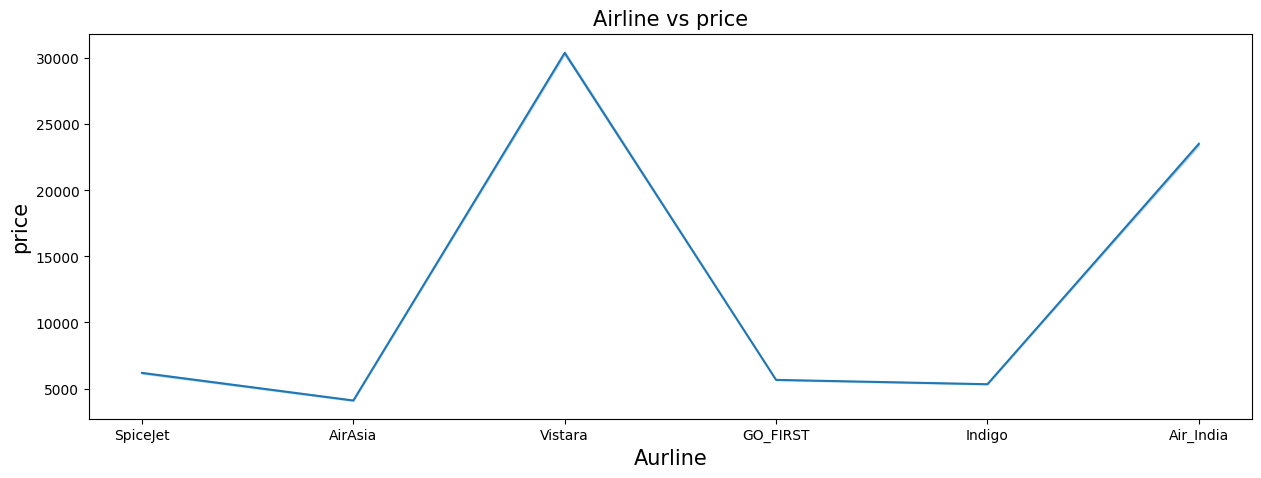

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
sns.lineplot(x=df['airline'],y=df['price'])
plt.title('Airline vs price',fontsize=15)
plt.xlabel('Aurline',fontsize=15)
plt.ylabel('price',fontsize=15)
plt.show()

**Data Visualization**

The price of the ticket
increases as the days left for
departure decreases

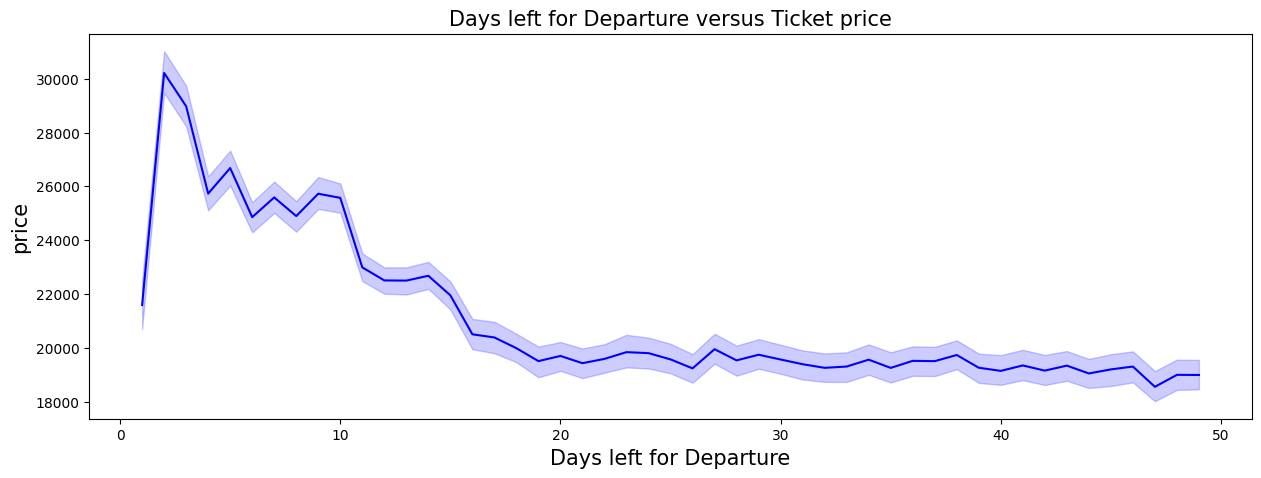

In [8]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df,x='days_left',y='price',color='Blue')
plt.title('Days left for Departure versus Ticket price',fontsize=15)
plt.xlabel('Days left for Departure',fontsize=15)
plt.ylabel('price',fontsize=15)
plt.show()


**Data Visualization**

Price range of all the flights

<Axes: xlabel='airline', ylabel='price'>

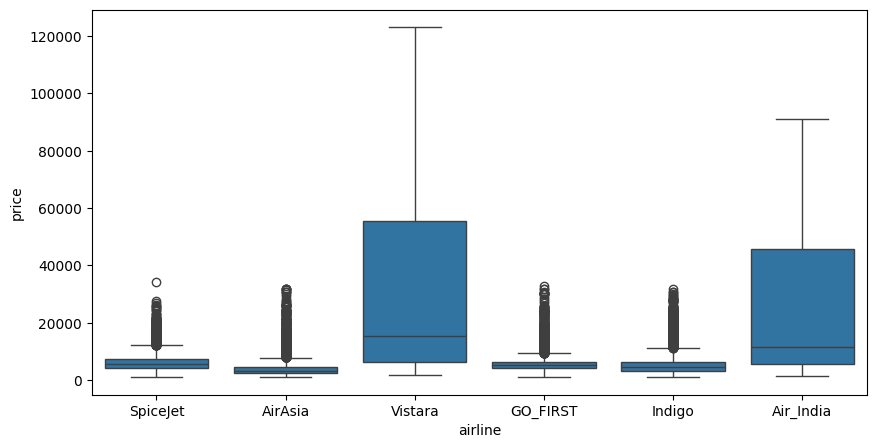

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x='airline', y='price', data=df)

**Data Visualization**

Range of price of all the
flights of Economy and
Business class

<Axes: xlabel='class', ylabel='price'>

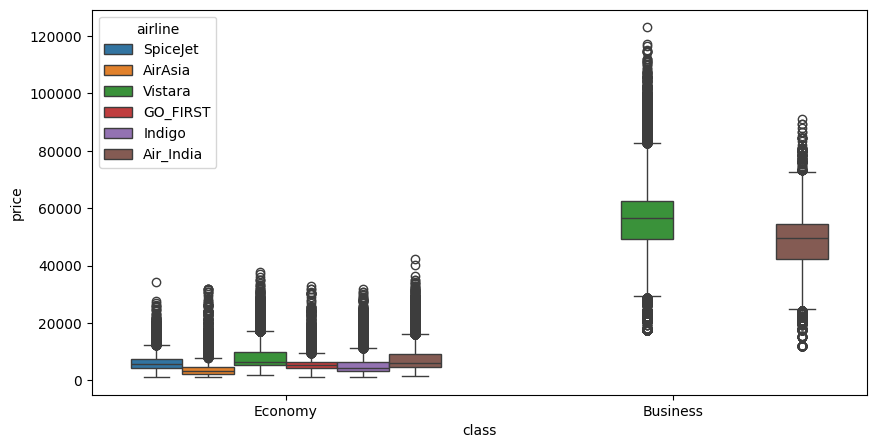

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class', y='price', data=df,hue='airline')

**Data Visualization**

Range of price of flights with source
and destination city according to
the  days left

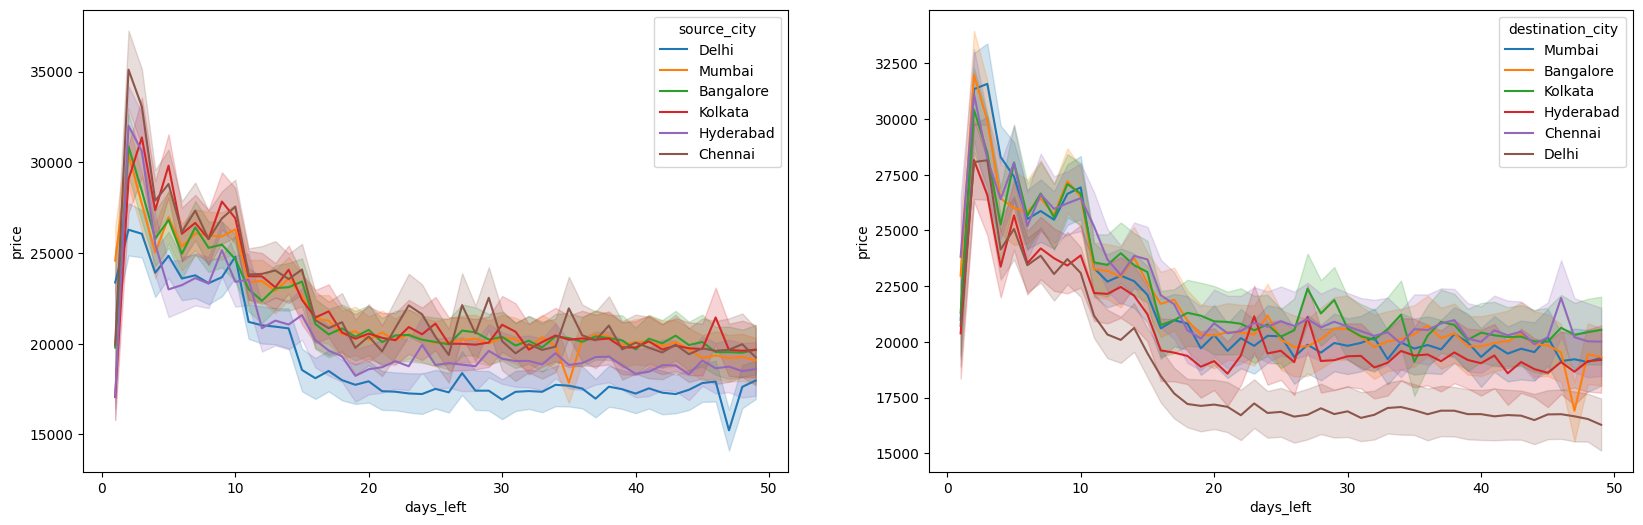

In [11]:
fig, ax=plt.subplots(1,2,figsize=(20,6))
sns.lineplot(x='days_left',y='price',data=df,hue='source_city',ax=ax[0])
sns.lineplot(x='days_left',y='price',data=df,hue='destination_city',ax=ax[1])
plt.show()


**Data Visualization**

Visualization of categorical features with countplot

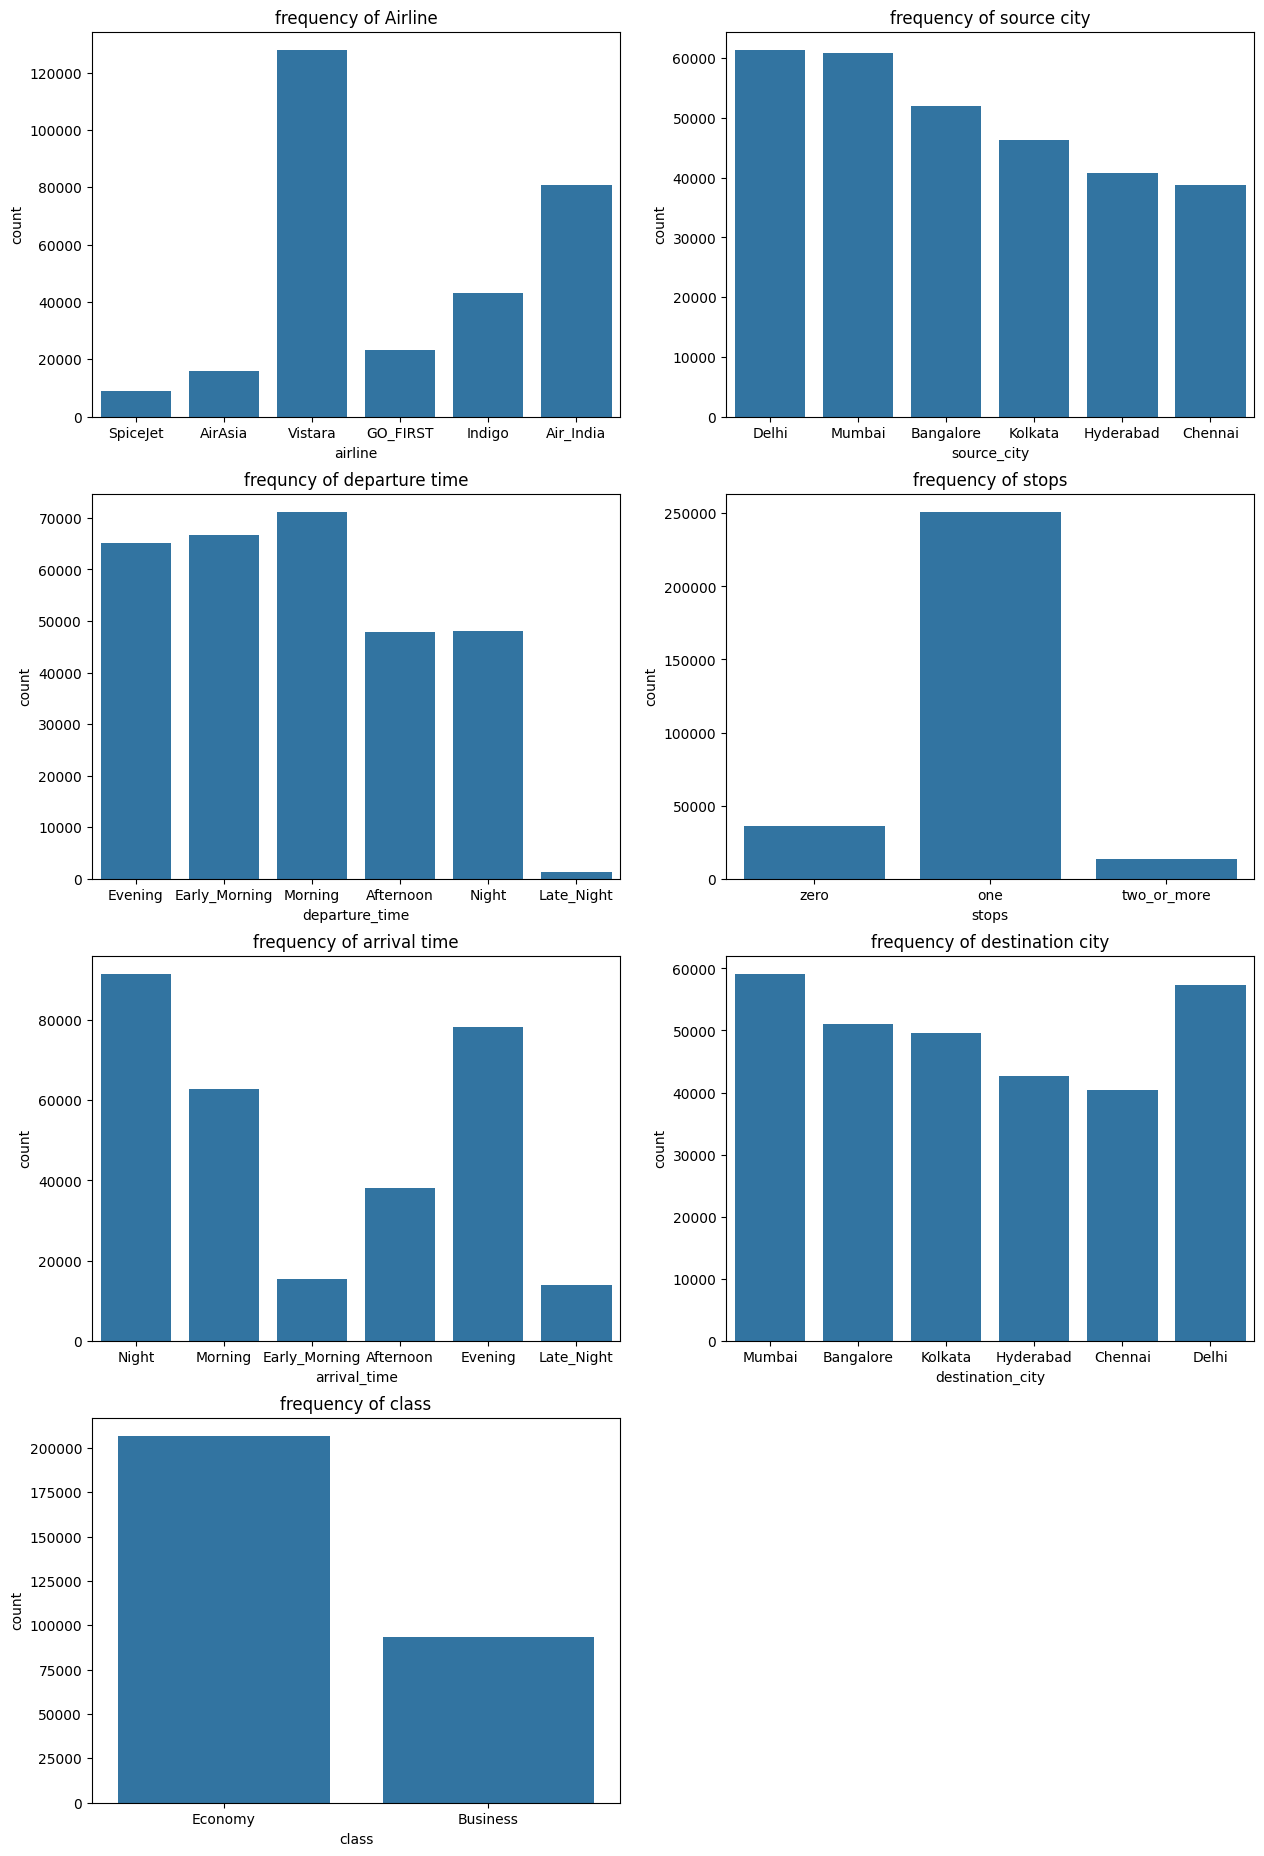

In [12]:
plt.figure(figsize=(15,23))

plt.subplot(4,2,1)
sns.countplot(x=df["airline"], data=df)
plt.title("frequency of Airline")

plt.subplot(4,2,2)
sns.countplot(x=df["source_city"], data=df)
plt.title("frequency of source city")

plt.subplot(4,2,3)
sns.countplot(x=df["departure_time"], data=df)
plt.title("frequncy of departure time")

plt.subplot(4,2,4)
sns.countplot(x=df["stops"], data=df)
plt.title("frequency of stops")

plt.subplot(4,2,5)
sns.countplot(x=df["arrival_time"], data=df)
plt.title("frequency of arrival time")

plt.subplot(4,2,6)
sns.countplot(x=df["destination_city"], data=df)
plt.title("frequency of destination city")

plt.subplot(4,2,7)
sns.countplot(x=df["class"], data=df)
plt.title("frequency of class")

plt.show()

**Label Encoding**

Performing One Hot Encoding for categorical features of a
dataframe

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["airline"]=le.fit_transform(df["airline"])
df["source_city"]=le.fit_transform(df["source_city"])
df["departure_time"]=le.fit_transform(df["departure_time"])
df["stops"]=le.fit_transform(df["stops"])
df["arrival_time"]=le.fit_transform(df["arrival_time"])
df["destination_city"]=le.fit_transform(df["destination_city"])
df["class"]=le.fit_transform(df["class"])
df = df.drop(columns=['stop'], errors='ignore') # Drop the redundant 'stop' column if it exists
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,SG-8709,2,2,2,5,5,1,2.17,1,5953
1,4,SG-8157,2,1,2,4,5,1,2.33,1,5953
2,0,I5-764,2,1,2,1,5,1,2.17,1,5956
3,5,UK-995,2,4,2,0,5,1,2.25,1,5955
4,5,UK-963,2,4,2,4,5,1,2.33,1,5955


**Feature Selection**

Plotting the correlation
graph to see the
correlation between
features and dependent
variable.

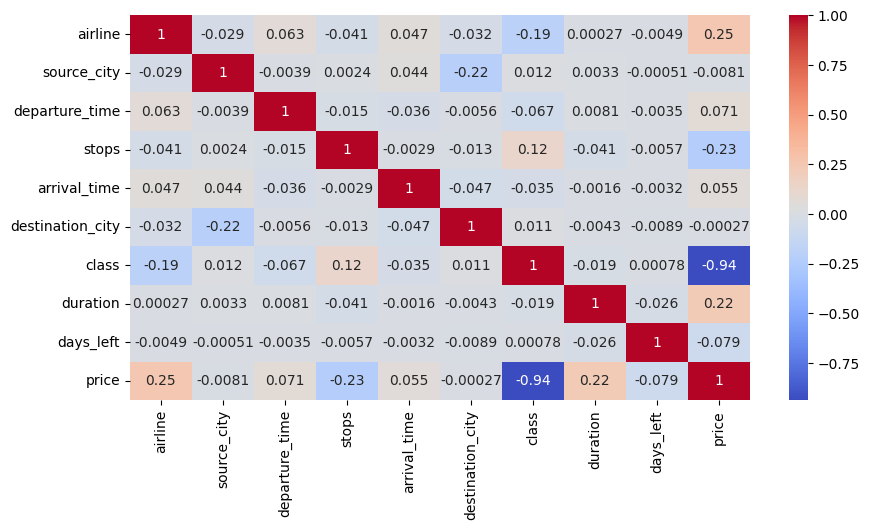

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df.drop('flight', axis=1).corr(),annot=True,cmap="coolwarm")
plt.show()

**Feature Selection**

Selecting the features using
VIF. VIF should be less than 5.
So drop the stops feature.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list =[]

# Collect all relevant numerical columns (excluding 'price')
for col in df.columns:
  if ((df[col].dtype != 'object') & (col != 'price')):
    col_list.append(col)

# Create the DataFrame for VIF calculation using the collected columns
x = df[col_list]

# Explicitly handle NaN and inf values before VIF calculation
# Replace infinite values with NaN and then drop rows with NaN
if x.isnull().any().any() or (x == np.inf).any().any() or (x == -np.inf).any().any():
    print("Warning: NaN or Inf values found in data for VIF calculation. Dropping rows with such values.")
    x = x.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF only if there are enough columns and valid data remains
if len(x.columns) > 1 and not x.empty:
    vif_data = pd.DataFrame()
    vif_data["feature"] = x.columns
    vif_data["VIF"]=[variance_inflation_factor(x.values, i)
    for i in range(len(x.columns))]
    print(vif_data)
else:
    print("Cannot calculate VIF (not enough columns or data after cleaning).")

            feature        VIF
0           airline   3.774677
1       source_city   3.300559
2    departure_time   2.754851
3             stops  21.673491
4      arrival_time   9.041602
5  destination_city   8.138874
6             class  22.192332
7          duration   4.017190
8         days_left   3.443682


**Feature Selection**

Dropping the stops column.
All features are having VIF
less than 5.

In [22]:
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

df=df.drop(columns=["stops"]) # Corrected column name to 'stops'

col_list =[]
# Collect all relevant numerical columns (excluding 'price')
for col in df.columns:
  if ((df[col].dtype != 'object') & (col != 'price')):
    col_list.append(col)

# Create the DataFrame for VIF calculation using the collected columns
x = df[col_list]

# Explicitly handle NaN and inf values before VIF calculation
# Replace infinite values with NaN and then drop rows with NaN
if x.isnull().any().any() or (x == np.inf).any().any() or (x == -np.inf).any().any():
    print("Warning: NaN or Inf values found in data for VIF calculation. Dropping rows with such values.")
    x = x.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF only if there are enough columns and valid data remains
if len(x.columns) > 1 and not x.empty:
    vif_data = pd.DataFrame()
    vif_data["feature"] = x.columns
    vif_data["VIF"]=[variance_inflation_factor(x.values, i)
    for i in range(len(x.columns))]
    print(vif_data)
else:
    print("Cannot calculate VIF (not enough columns or data after cleaning).")

            feature        VIF
0           airline   3.655112
1       source_city   3.226684
2    departure_time   2.705094
3      arrival_time   8.520881
4  destination_city   7.680856
5             class  14.517998
6          duration   3.781996
7         days_left   3.404040


**Linear Regression**

Applying standardization and implementing Linear Regression Model to
predict the price of a flight.

In [14]:
x=df.drop(columns=["price", "flight"]) # Drop 'flight' column as it contains string values
y=df['price']

# Combine x and y for synchronized dropping of NaNs/Infs
# This ensures that both x and y have no NaNs and their indices are aligned
combined_df = pd.concat([x, y], axis=1)

# Handle infinite values (replace with NaN) and then drop rows with NaNs
initial_rows = len(combined_df)
combined_df = combined_df.replace([np.inf, -np.inf], np.nan).dropna()
rows_dropped = initial_rows - len(combined_df)
if rows_dropped > 0:
    print(f"Warning: Dropped {rows_dropped} rows from data due to NaN/Inf values, ensuring x and y are aligned.")

x = combined_df.drop(columns=['price'])
y = combined_df['price']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
difference=pd.DataFrame(np.c_[y_test,y_pred],columns=["Actual_value","predicted_value"])
difference

,Actual_value,predicted_value
0,7366.0,4585.880510
1,64831.0,52842.077073
2,6195.0,7877.980184
3,60160.0,56120.138579
4,6578.0,6663.204177
...,...,...
60026,5026.0,5829.230618
60027,3001.0,539.222230
60028,6734.0,5848.965500
60029,5082.0,-1498.061918


**Linear Regression**

Calculating r2 score,MAE, MAPE, MSE, RMSE. Root Mean square error(RMSE)
of the Linear regression model is 7259.93 and Mean absolute percentage
error(MAPE) is 34 percent. Lower the RMSE and MAPE better the model.

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test,y_pred)}")

mean_sq_error = mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error (MSE): {mean_sq_error}")

root_mean_squared_error = np.sqrt(mean_sq_error)
print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error}")

R2 Score: 0.904554350718816
Mean Absolute Error (MAE): 4624.994868016881
Mean Absolute Percentage Error (MAPE): 0.4353581089683269
Mean Squared Error (MSE): 49200540.293722
Root Mean Squared Error (RMSE): 7014.309680483319


**Linear Regression**

Plotting the graph of actual
and predicted price of flight

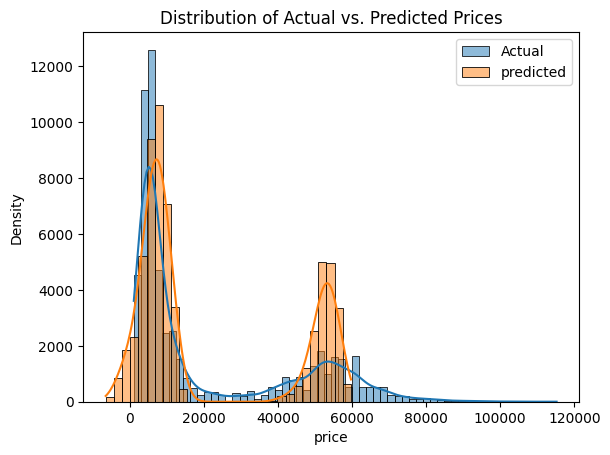

In [20]:
sns.histplot(y_test, label="Actual", kde=True)
sns.histplot(y_pred, label="predicted", kde=True)
plt.legend()
plt.xlabel("price")
plt.ylabel("Density")
plt.title("Distribution of Actual vs. Predicted Prices")
plt.show()

**Decision Tree Regressor**

Mean absolute percentage
error is 7.7 percent and RMSE
is 3620 which is less than the
linear regression model

In [31]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

# Ensure all necessary metrics are imported from sklearn.metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test,y_pred)}")

mean_sq_error=mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error (MSE): {mean_sq_error}")

root_mean_sq_error = np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Root Mean Squared Error (RMSE): {root_mean_sq_error}")

R2 Score: 0.9752819893551409
Mean Absolute Error (MAE): 1181.2454953829413
Mean Absolute Percentage Error (MAPE): 0.07430467510438692
Mean Squared Error (MSE): 12741696.325311553
Root Mean Squared Error (RMSE): 3569.551277865546


**Random Forest Regressor**

Mean absolute percentage
error is  7.3 percent and RMSE
is 2824 which is less than the
linear regression and decision
tree model

R2 Score: 0.9848644612289793
Mean Absolute Error (MAE): 1091.349020647371
Mean Absolute Percentage Error (MAPE): 0.07026456849688845
Mean Squared Error (MSE): 7802101.937375575
Root Mean Squared Error (RMSE): 2793.2242905602075


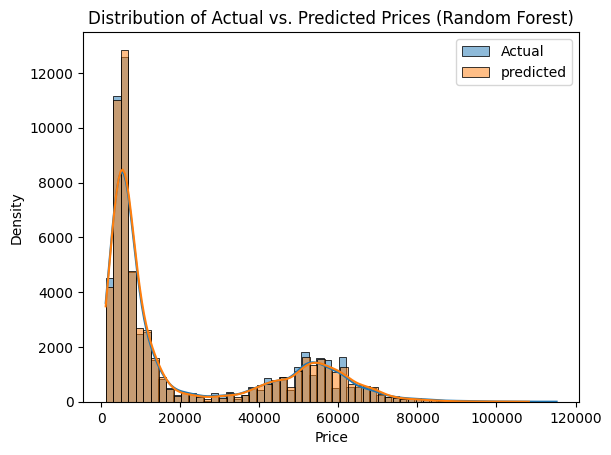

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rfr=RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)

print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test,y_pred)}")

mean_sq_error=mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error (MSE): {mean_sq_error}")

root_mean_sq_error = np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Root Mean Squared Error (RMSE): {root_mean_sq_error}")

sns.histplot(y_test, label="Actual", kde=True)
sns.histplot(y_pred, label="predicted", kde=True)
plt.legend()
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Distribution of Actual vs. Predicted Prices (Random Forest)")
plt.show()